In [2]:
import sys, os
from pathlib import Path

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
    os.chdir(ROOT)
sys.path.insert(0, str(ROOT))
%matplotlib inline

print(Path.cwd())

d:\Mathematical Modelling with Python\turbulent-channel-solver


In [3]:
from channel import solve_quadrature, load_case, MixingLength
import numpy as np

sol = solve_quadrature(587.19)
dns = load_case(590)
print(sol.summary())

Re_tau=587.19  U_b+=17.5135  Re_b=20567.5  Cf=6.52056e-03


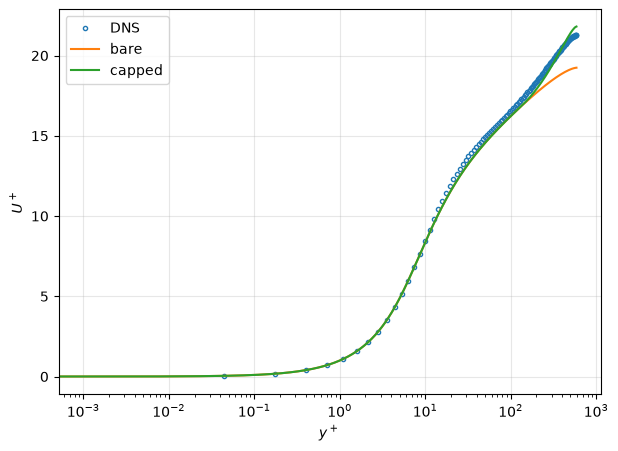

In [4]:
import matplotlib.pyplot as plt

capped = solve_quadrature(587.19, model=MixingLength(lambda_outer=0.09, Re_tau=587.19))

fig, ax = plt.subplots(figsize=(7, 5))
ax.semilogx(dns.y_plus[1:], dns.U_plus[1:], 'o', ms=3, mfc='none', label='DNS')
ax.semilogx(sol.y_plus, sol.U_plus, label='bare')
ax.semilogx(capped.y_plus, capped.U_plus, label='capped')
ax.set_xlabel('$y^+$'); ax.set_ylabel('$U^+$'); ax.legend(); ax.grid(alpha=0.3)

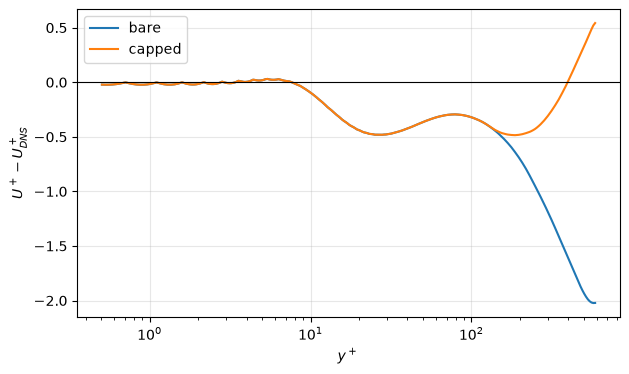

In [5]:
yq = sol.y_plus[sol.y_plus > 0.5]
fig, ax = plt.subplots(figsize=(7, 4))
for s, lbl in ((sol, 'bare'), (capped, 'capped')):
    u = np.interp(yq, s.y_plus, s.U_plus)
    ax.semilogx(yq, u - dns.interpolate(yq), label=lbl)
ax.axhline(0, color='k', lw=0.8)
ax.set_xlabel('$y^+$'); ax.set_ylabel('$U^+ - U^+_{DNS}$'); ax.legend(); ax.grid(alpha=0.3)

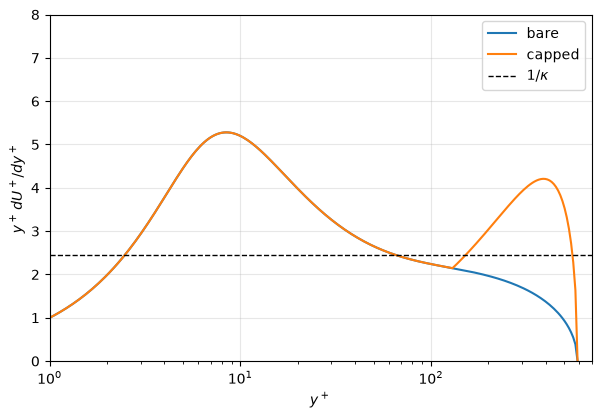

In [6]:
fig, ax = plt.subplots(figsize=(7, 4.5))
for s, lbl in ((sol, 'bare'), (capped, 'capped')):
    ax.semilogx(s.y_plus, s.y_plus * s.dUdy_plus, label=lbl)
ax.axhline(1/0.41, color='k', ls='--', lw=1, label=r'$1/\kappa$')
ax.set_xlim(1, 700); ax.set_ylim(0, 8)
ax.set_xlabel('$y^+$'); ax.set_ylabel(r'$y^+\,dU^+/dy^+$')
ax.legend(); ax.grid(alpha=0.3)

Text(0.5, 0, '$y^+$')

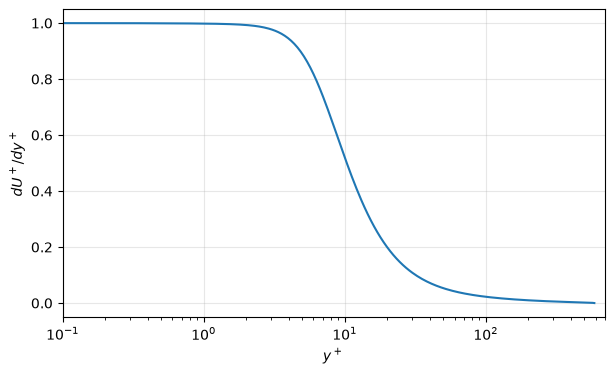

In [8]:
fig, ax = plt.subplots(figsize=(7,4))
ax.semilogx(sol.y_plus, sol.dUdy_plus)
ax.set_xlim(0.1,700); ax.set_ylabel(r'$dU^+/dy^+$'); ax.grid(alpha=0.3)
ax.set_xlabel('$y^+$')

In [9]:
hi = solve_quadrature(5200.0)

print(f'{"y+":>7} {"dU+/dy+":>10} {"x y+":>8}')
for y in (30, 60, 100, 200, 400, 800, 1500, 3000, 5200):
    g = np.interp(y, hi.y_plus, hi.dUdy_plus)
    print(f'{y:7.0f} {g:10.5f} {g*y:8.2f}')

     y+    dU+/dy+     x y+
     30    0.11158     3.35
     60    0.04388     2.63
    100    0.02438     2.44
    200    0.01189     2.38
    400    0.00584     2.34
    800    0.00280     2.24
   1500    0.00137     2.06
   3000    0.00053     1.59
   5200    0.00000     0.00


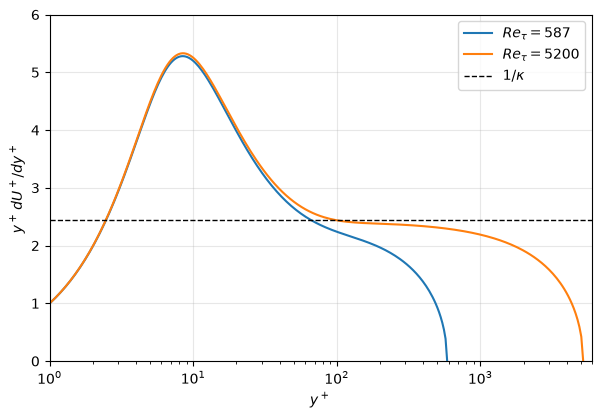

In [10]:
fig, ax = plt.subplots(figsize=(7, 4.5))
for s, lbl in ((sol, r'$Re_\tau=587$'), (hi, r'$Re_\tau=5200$')):
    ax.semilogx(s.y_plus, s.y_plus * s.dUdy_plus, label=lbl)
ax.axhline(1/0.41, color='k', ls='--', lw=1, label=r'$1/\kappa$')
ax.set_xlim(1, 6000); ax.set_ylim(0, 6)
ax.set_xlabel('$y^+$'); ax.set_ylabel(r'$y^+\,dU^+/dy^+$')
ax.legend(); ax.grid(alpha=0.3)

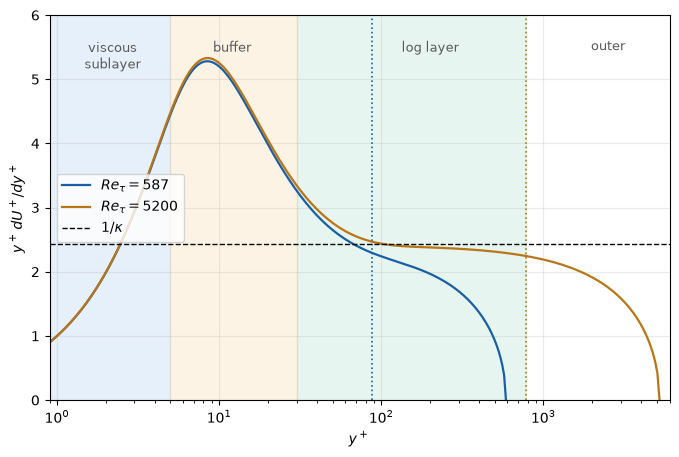

In [11]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.axvspan(0.9, 5, color='#378ADD', alpha=0.12)
ax.axvspan(5, 30, color='#EF9F27', alpha=0.12)
ax.axvspan(30, 0.15*5200, color='#1D9E75', alpha=0.10)

ax.axvline(0.15*587.19, color='#185FA5', ls=':', lw=1.2)
ax.axvline(0.15*5200,   color='#BA7517', ls=':', lw=1.2)

for s, lbl, c in ((sol, r'$Re_\tau=587$', '#185FA5'), (hi, r'$Re_\tau=5200$', '#BA7517')):
    ax.semilogx(s.y_plus, s.y_plus*s.dUdy_plus, label=lbl, color=c, lw=1.6)
ax.axhline(1/0.41, color='k', ls='--', lw=1, label=r'$1/\kappa$')

for x, txt in ((2.2, 'viscous\nsublayer'), (12, 'buffer'), (200, 'log layer'), (2500, 'outer')):
    ax.text(x, 5.6, txt, ha='center', va='top', fontsize=9, color='0.35')

ax.set_xlim(0.9, 6000); ax.set_ylim(0, 6)
ax.set_xlabel('$y^+$'); ax.set_ylabel(r'$y^+\,dU^+/dy^+$')
ax.legend(loc='center left'); ax.grid(alpha=0.25)

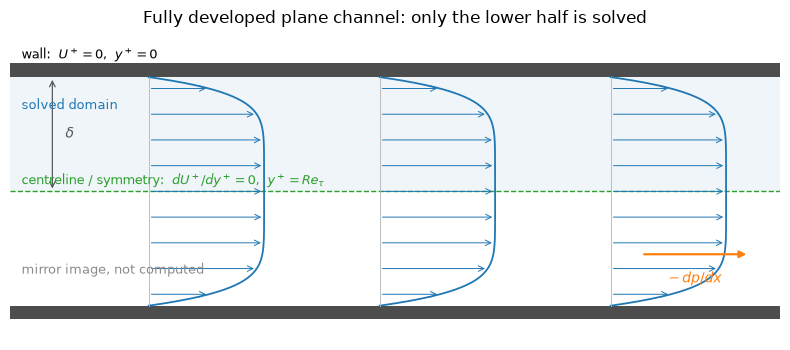

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

fig, ax = plt.subplots(figsize=(8, 3.6))

# walls
ax.add_patch(Rectangle((0, 1.0), 10, 0.12, fc="0.3", ec="none"))
ax.add_patch(Rectangle((0, -1.12), 10, 0.12, fc="0.3", ec="none"))

# solved half
ax.add_patch(Rectangle((0, 0), 10, 1.0, fc="tab:blue", alpha=0.07, ec="none"))

# centreline
ax.axhline(0, color="tab:green", lw=1.0, ls="--")

# velocity profiles at three stations, identical because fully developed
y = np.linspace(-1, 1, 200)
U = 1.0 - np.abs(y) ** 7
for x0 in (1.8, 4.8, 7.8):
    ax.plot(x0 + 1.5 * U, y, color="tab:blue", lw=1.3)
    ax.plot([x0, x0], [-1, 1], color="0.7", lw=0.6)
    for yv in np.linspace(-0.9, 0.9, 9):
        ax.annotate("", xy=(x0 + 1.5 * (1 - abs(yv) ** 7), yv), xytext=(x0, yv),
                    arrowprops=dict(arrowstyle="->", lw=0.7, color="tab:blue"))

# driving pressure gradient
ax.annotate("", xy=(9.6, -0.55), xytext=(8.2, -0.55),
            arrowprops=dict(arrowstyle="-|>", lw=1.6, color="tab:orange"))
ax.text(8.9, -0.8, r"$-\,dp/dx$", color="tab:orange", ha="center")

# wall-normal extent
ax.annotate("", xy=(0.55, 1.0), xytext=(0.55, 0),
            arrowprops=dict(arrowstyle="<->", lw=0.9, color="0.35"))
ax.text(0.72, 0.5, r"$\delta$", color="0.35", va="center")

ax.text(0.15, 1.16, r"wall:  $U^+ = 0$,  $y^+ = 0$", fontsize=9)
ax.text(0.15, 0.06, r"centreline / symmetry:  $dU^+/dy^+ = 0$,  $y^+ = Re_\tau$",
        color="tab:green", fontsize=9)
ax.text(0.15, 0.72, "solved domain", color="tab:blue", fontsize=9)
ax.text(0.15, -0.72, "mirror image, not computed", color="0.55", fontsize=9)

ax.set_xlim(0, 10); ax.set_ylim(-1.3, 1.4)
ax.set_xticks([]); ax.set_yticks([])
for s in ax.spines.values():
    s.set_visible(False)
ax.set_title("Fully developed plane channel: only the lower half is solved")
plt.tight_layout()
plt.show()